# Implémentation originale de Lakhina Entropy

Ce notebook exécute l'adaptation locale de l'algorithme d'origine fournie dans `Lakhina_entropy_IDS.ipynb`.

Il reprend aussi l'exploration visuelle du premier `main`, puis déroule l'algorithme original :
chargement, exploration, entropies, PCA, calibration, figures, évaluation et récapitulatif final.

In [92]:
from copy import deepcopy
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from sklearn.metrics import classification_report

from analysis.statistics import (
    compute_entropy_preview,
    plot_feature_distributions,
    plot_label_distribution,
    plot_protocol_by_label,
    plot_traffic_over_time,
    print_summary,
)
from main_detection_original import (
    CONFIG as ORIGINAL_CONFIG,
    calculate_anomaly_scores,
    calibrate_thresholds,
    compute_binary_metrics,
    load_splits,
    perform_pca,
    plot_confusion,
    plot_threshold_heatmap,
    predict_anomalies,
    prepare_original_features,
    print_split_overview,
    save_outputs,
)
from preprocessing.loader import clean_dataframe, load_binetflow

In [93]:
CONFIG = deepcopy(ORIGINAL_CONFIG)
RESULTS_DIR = Path(CONFIG['results_dir'])
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def show_saved_figure(filename: str):
    display(Image(filename=str(RESULTS_DIR / filename)))

CONFIG

{'dataset_path': 'dataset/9/capture20110817.binetflow',
 'splits_dir': 'dataset/9/splits/',
 'results_dir': 'results_original/',
 'train_ratio': 0.6,
 'val_ratio': 0.2,
 'use_tcp_only': True,
 'malicious_threshold': 0.0,
 'pca_feature_columns': ('SrcPortEntropy',
  'DestPortEntropy',
  'DestIPEntropy',
  'FlagEntropy'),
 'eigen_threshold': 1e-06,
 'k_minor': 1,
 'threshold_grid_points': 80}

## 1. Exploration du dataset

Cette partie reprend les visualisations du premier `main` pour ne pas perdre le contexte global du dataset.

In [94]:
df_raw = load_binetflow(CONFIG['dataset_path'])
df = clean_dataframe(df_raw)
print_summary(df)
df.head()

[INFO] Chargement de capture20110817.binetflow...
[INFO] 2,087,508 flows chargés. Colonnes : ['StartTime', 'Dur', 'Proto', 'SrcAddr', 'Sport', 'Dir', 'DstAddr', 'Dport', 'State', 'sTos', 'dTos', 'TotPkts', 'TotBytes', 'SrcBytes', 'Label']
[INFO] Nettoyage : 0 lignes supprimées (0.0%)
RÉSUMÉ DU DATASET

Nombre total de flows         : 2,087,508
Période                       : 2011-08-17 11:34:49.436881 → 2011-08-17 17:12:13.867435
Durée capturée                : 0 days 05:37:24.430554

── Distribution des labels ──
  Background  : 1,872,554 (89.70%)  ███████████████████████████████████
  Botnet      :  184,987 ( 8.86%)  ███
  Normal      :   29,967 ( 1.44%)  

── Protocoles ──
  udp     : 1,629,194 (78.04%)
  tcp     :  431,554 (20.67%)
  icmp    :   21,856 ( 1.05%)
  rtp     :    1,588 ( 0.08%)
  igmp    :    1,523 ( 0.07%)
  rtcp    :    1,266 ( 0.06%)
  arp     :      432 ( 0.02%)
  ipv6-icmp:       48 ( 0.00%)
  ipv6    :       12 ( 0.00%)
  ipx/spx :       11 ( 0.00%)

── Statistiq

,StartTime,Dur,Proto,SrcAddr,Sport,Dir,DstAddr,Dport,State,sTos,dTos,TotPkts,TotBytes,SrcBytes,Label,Label_raw
0,2011-08-17 11:34:49.436881,1823.088379,udp,46.196.43.16,6881.0,<->,147.32.84.118,6881.0,CON,0.0,0.0,2,214,107,Background,flow=Background-UDP-Established
1,2011-08-17 11:39:01.485380,2005.431641,udp,82.1.195.156,6881.0,<->,147.32.84.118,6881.0,CON,0.0,0.0,2,214,107,Background,flow=Background-UDP-Established
2,2011-08-17 11:40:19.495285,1973.646729,udp,151.28.221.122,6881.0,<->,147.32.84.118,6881.0,CON,0.0,0.0,2,214,107,Background,flow=Background-UDP-Established
3,2011-08-17 12:01:01.780520,3599.997803,udp,188.75.133.98,16200.0,<->,147.32.86.125,35248.0,CON,0.0,0.0,409227,207547419,182657149,Background,flow=Background-UDP-Established
4,2011-08-17 12:01:01.782109,2059.387451,tcp,119.252.172.92,59067.0,<?>,147.32.84.14,80.0,RA_PA,0.0,0.0,224275,266462578,3199174,Background,flow=Background


[INFO] Figure sauvegardée : results_original/label_distribution.png


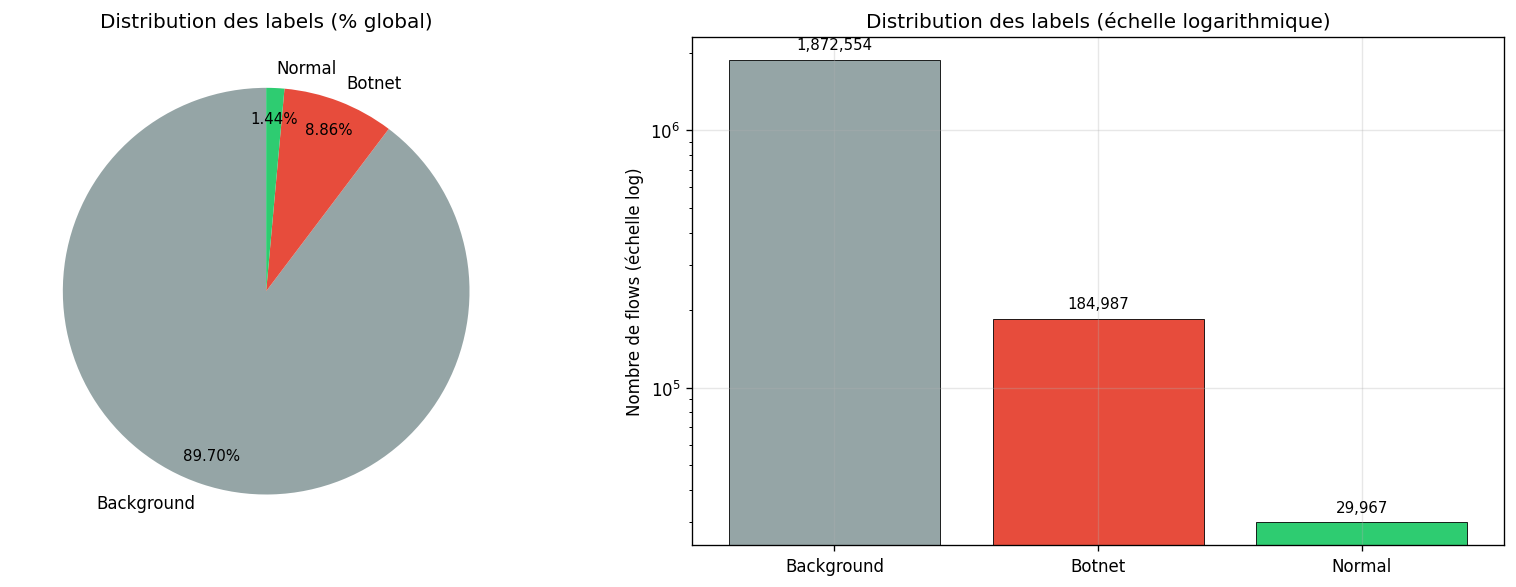

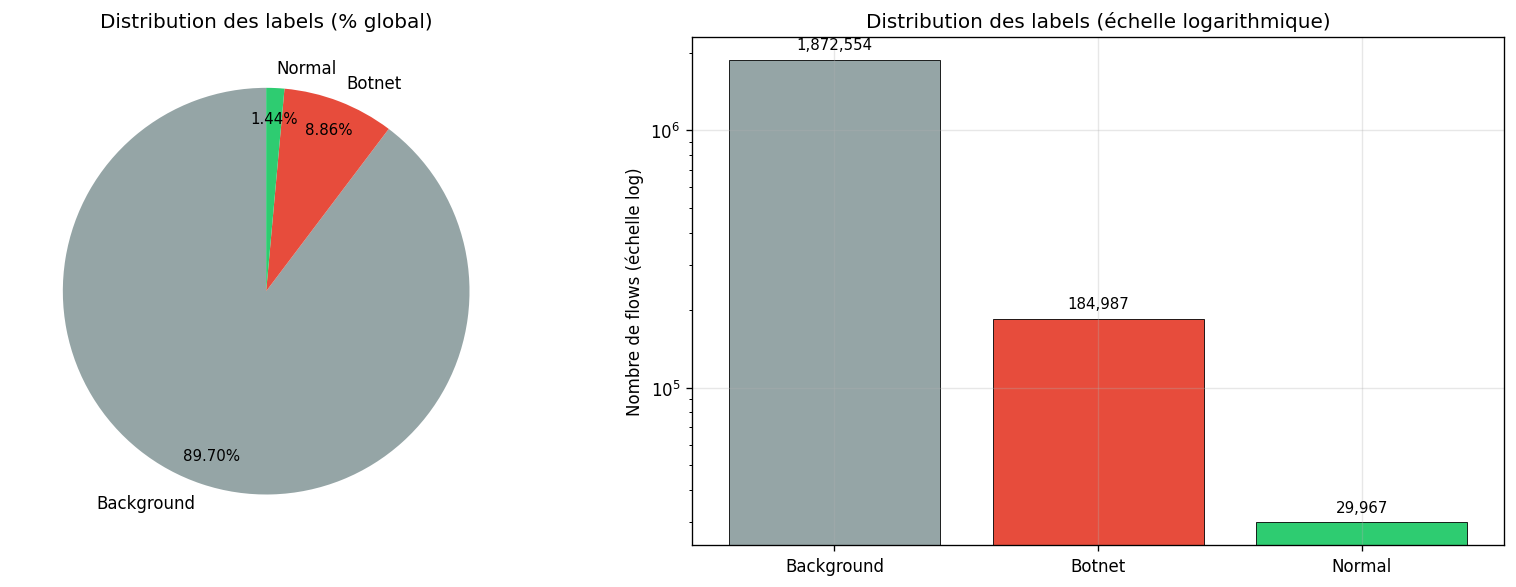

In [95]:
plot_label_distribution(df, str(RESULTS_DIR))
show_saved_figure('label_distribution.png')

[INFO] Figure sauvegardée : results_original/traffic_over_time.png


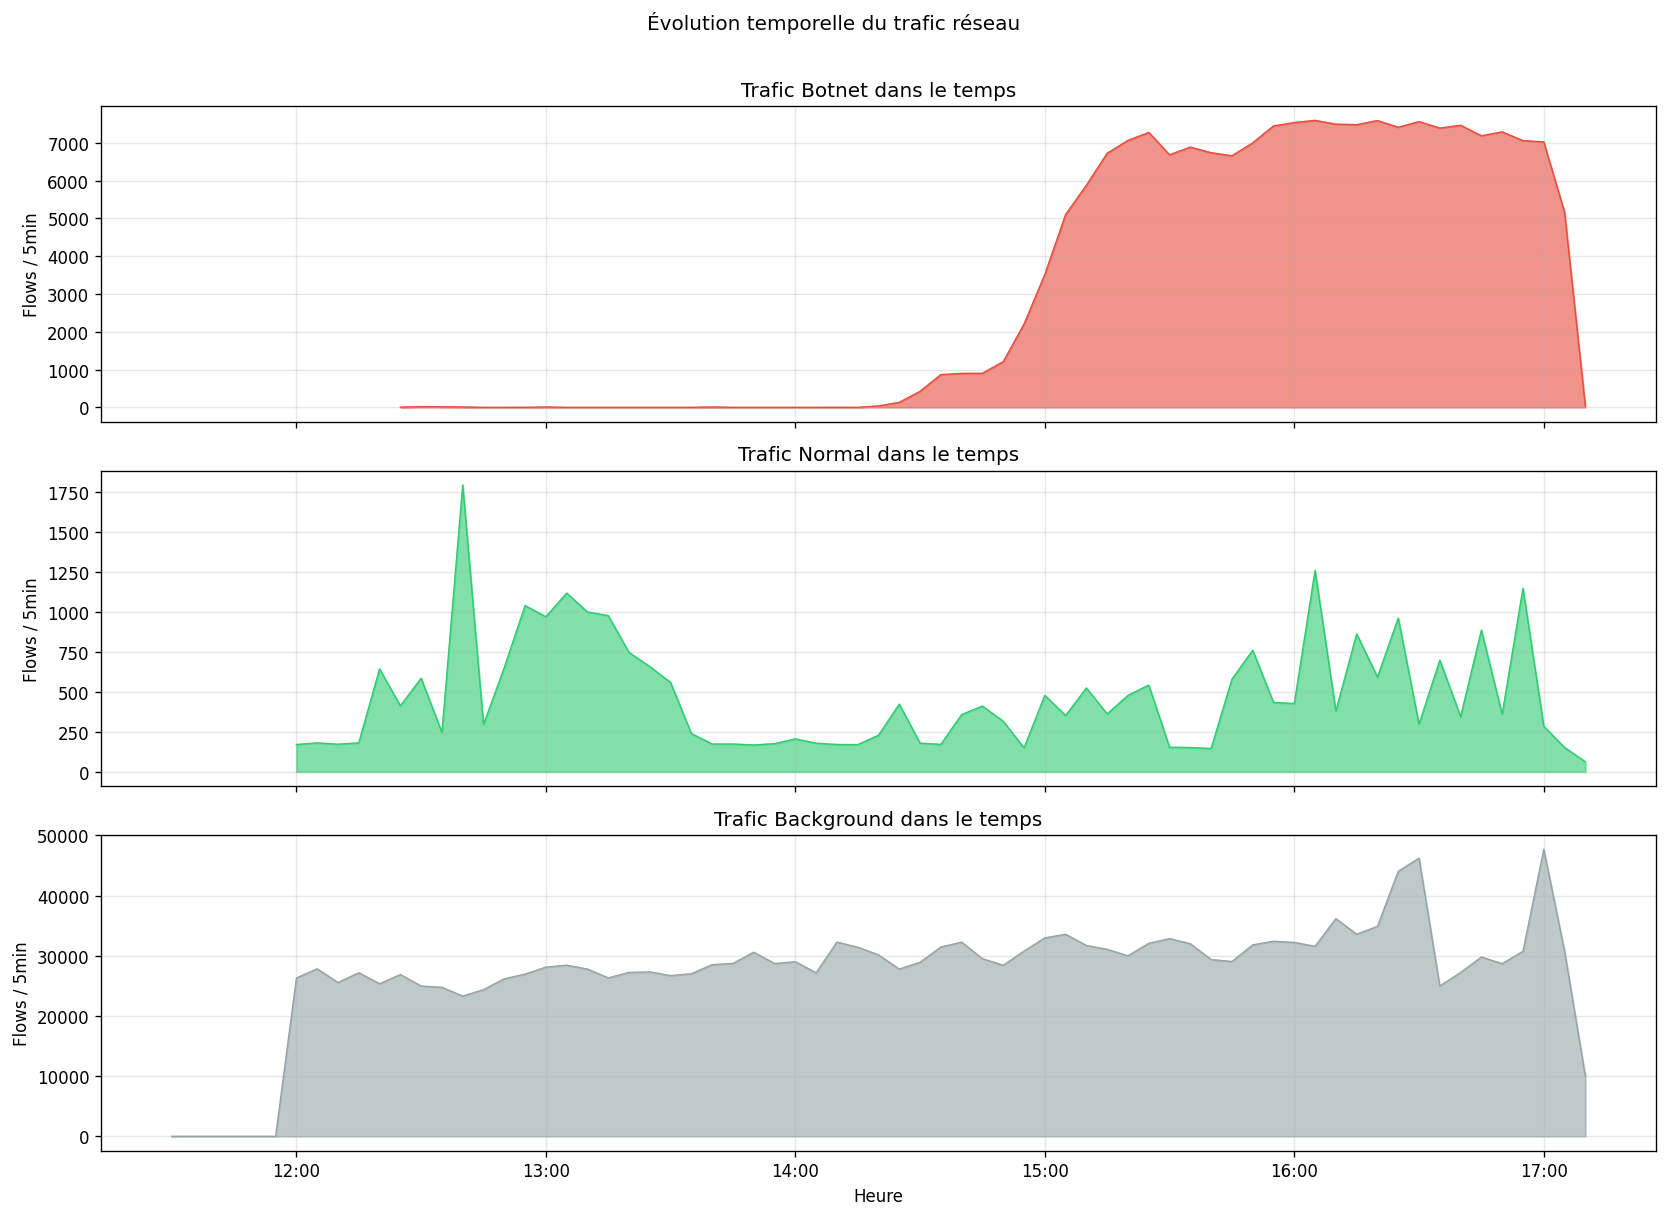

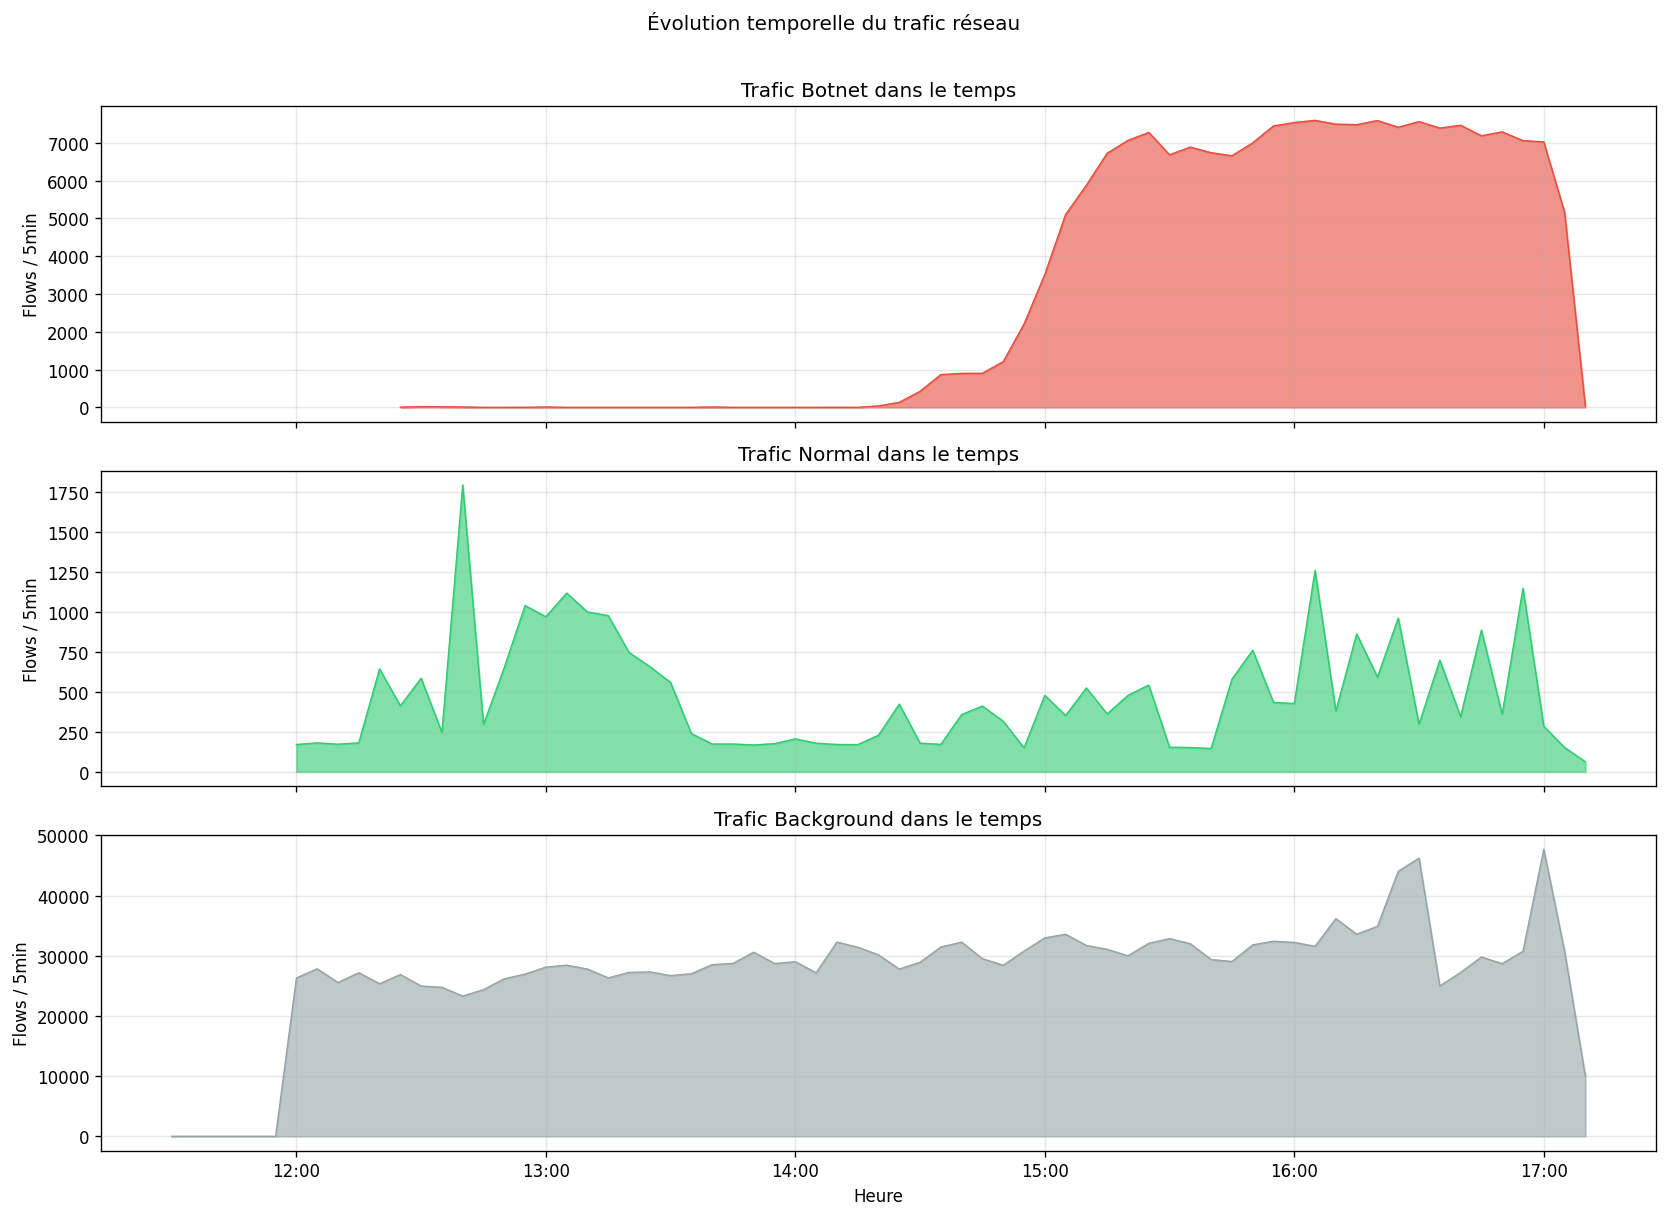

In [96]:
plot_traffic_over_time(df, window='5min', save_dir=str(RESULTS_DIR))
show_saved_figure('traffic_over_time.png')

[INFO] Figure sauvegardée : results_original/feature_distributions.png


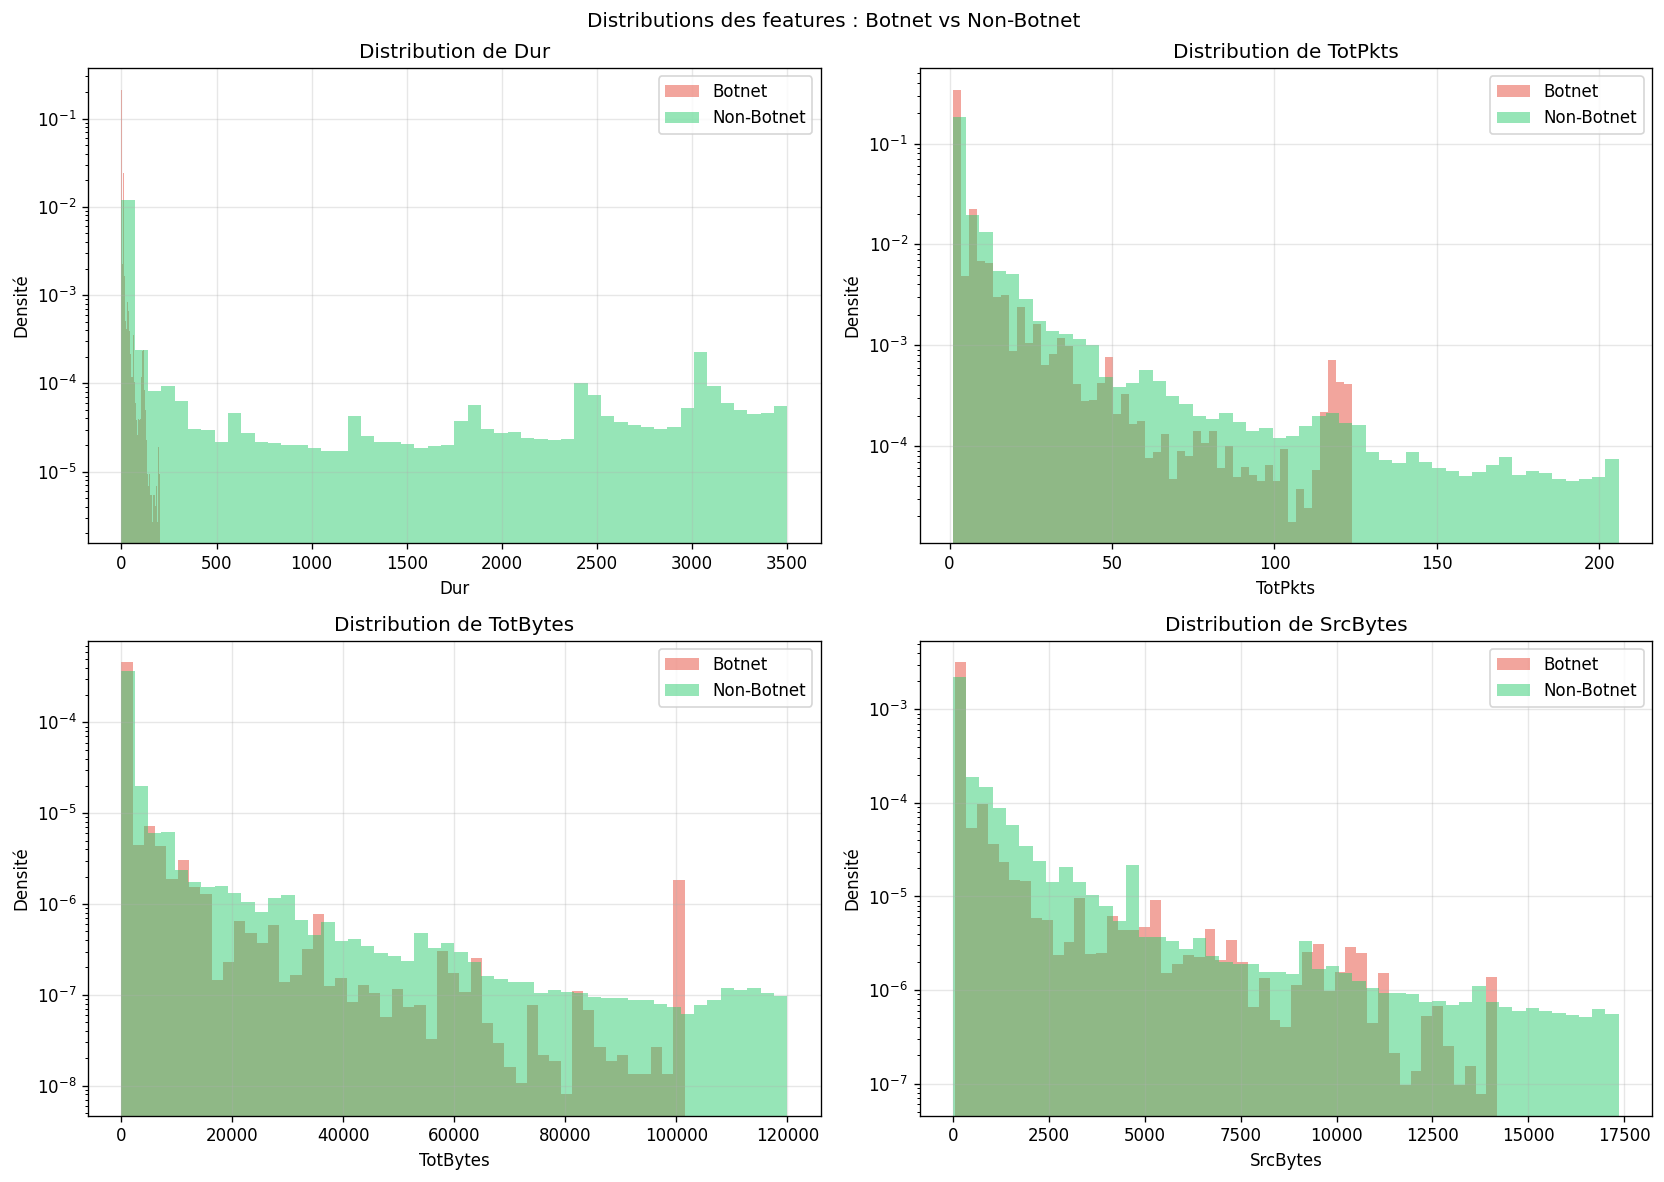

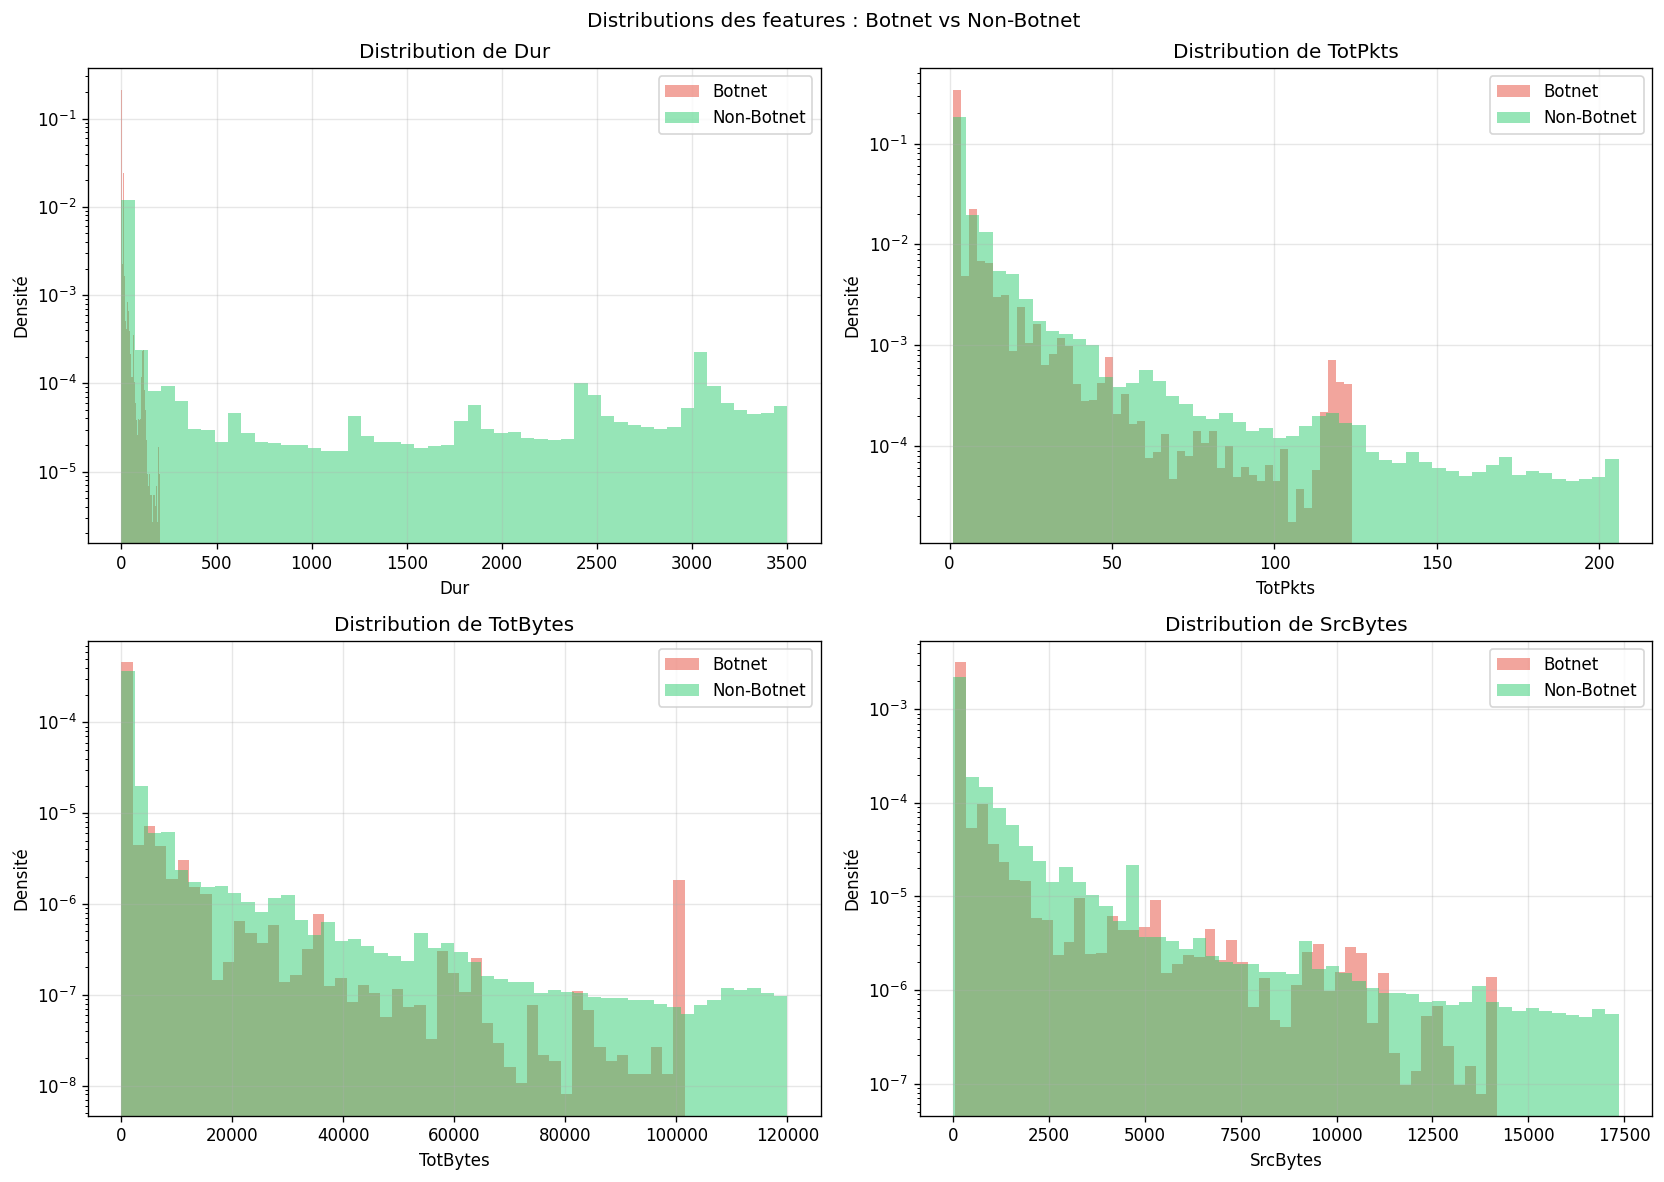

In [97]:
plot_feature_distributions(df, str(RESULTS_DIR))
show_saved_figure('feature_distributions.png')

[INFO] Figure sauvegardée : results_original/protocol_by_label.png


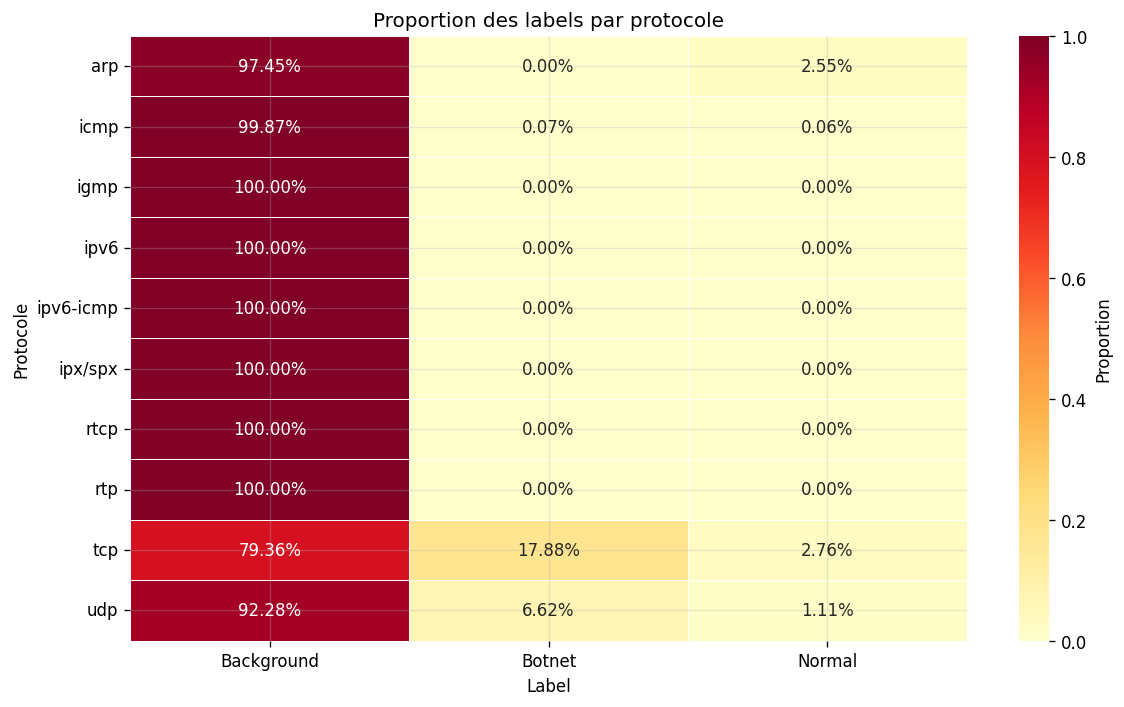

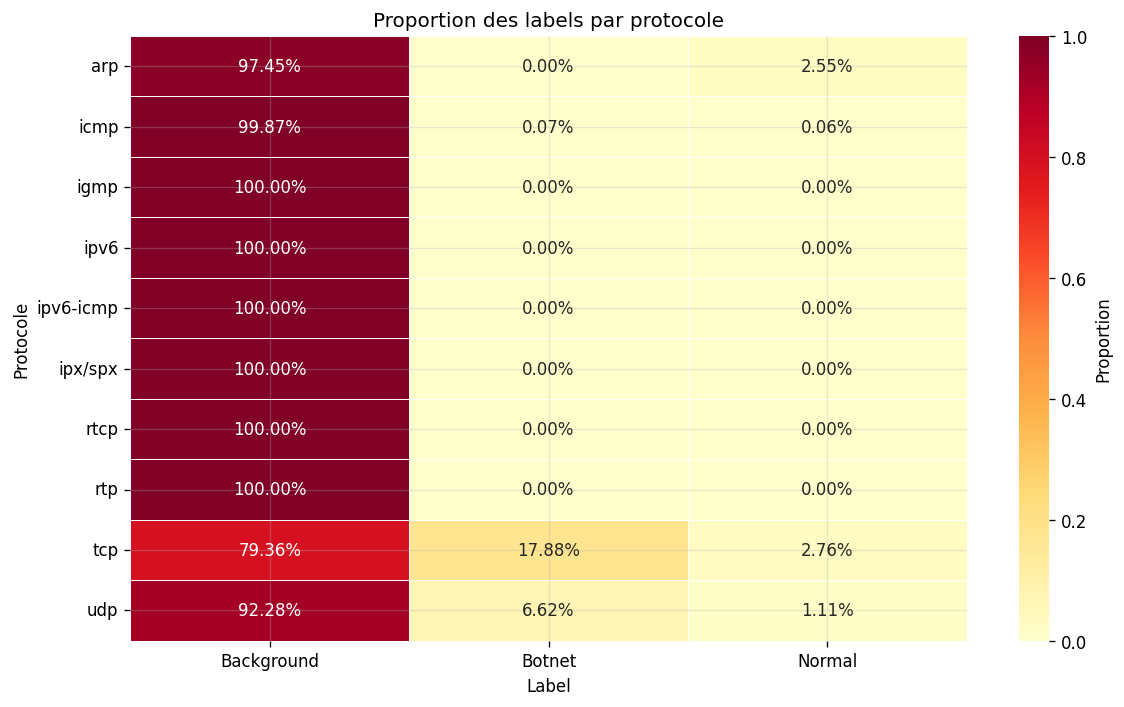

In [98]:
plot_protocol_by_label(df, str(RESULTS_DIR))
show_saved_figure('protocol_by_label.png')

[INFO] Calcul de l'aperçu d'entropie (peut prendre quelques secondes)...
[INFO] Figure sauvegardée : results_original/entropy_preview.png


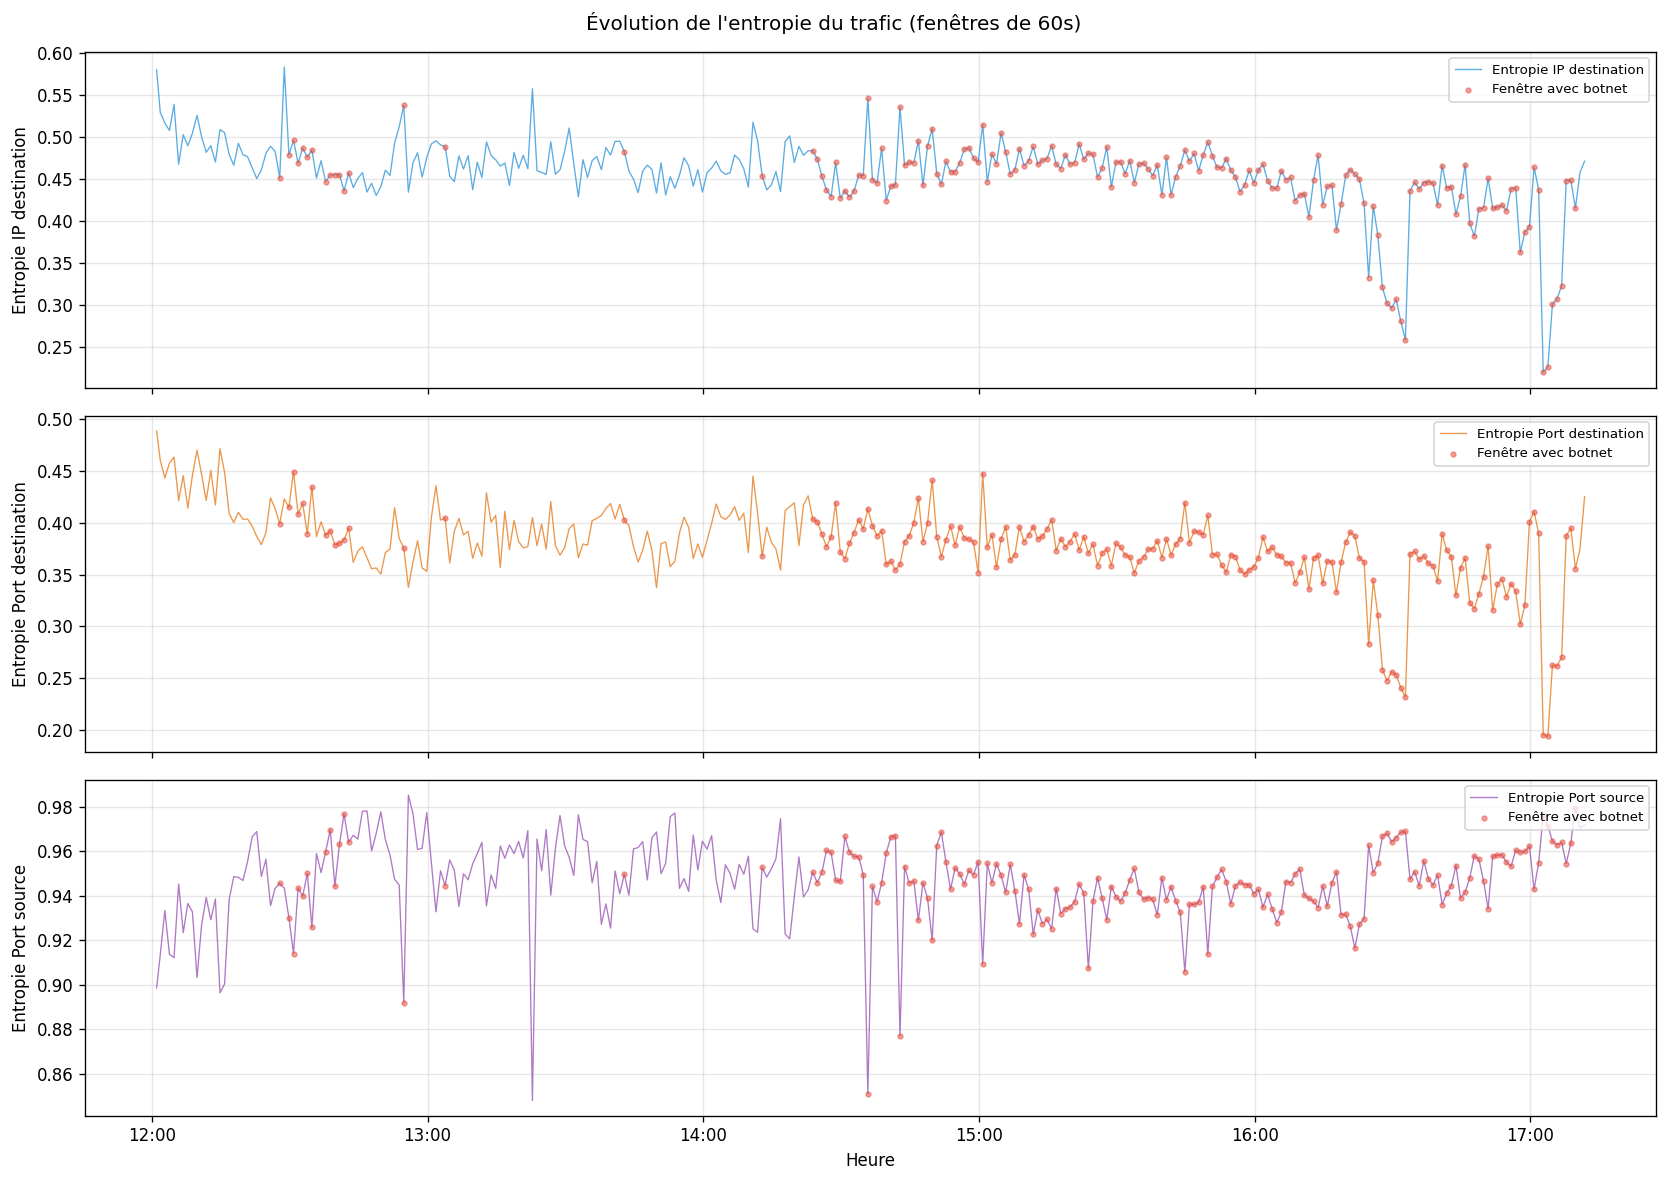

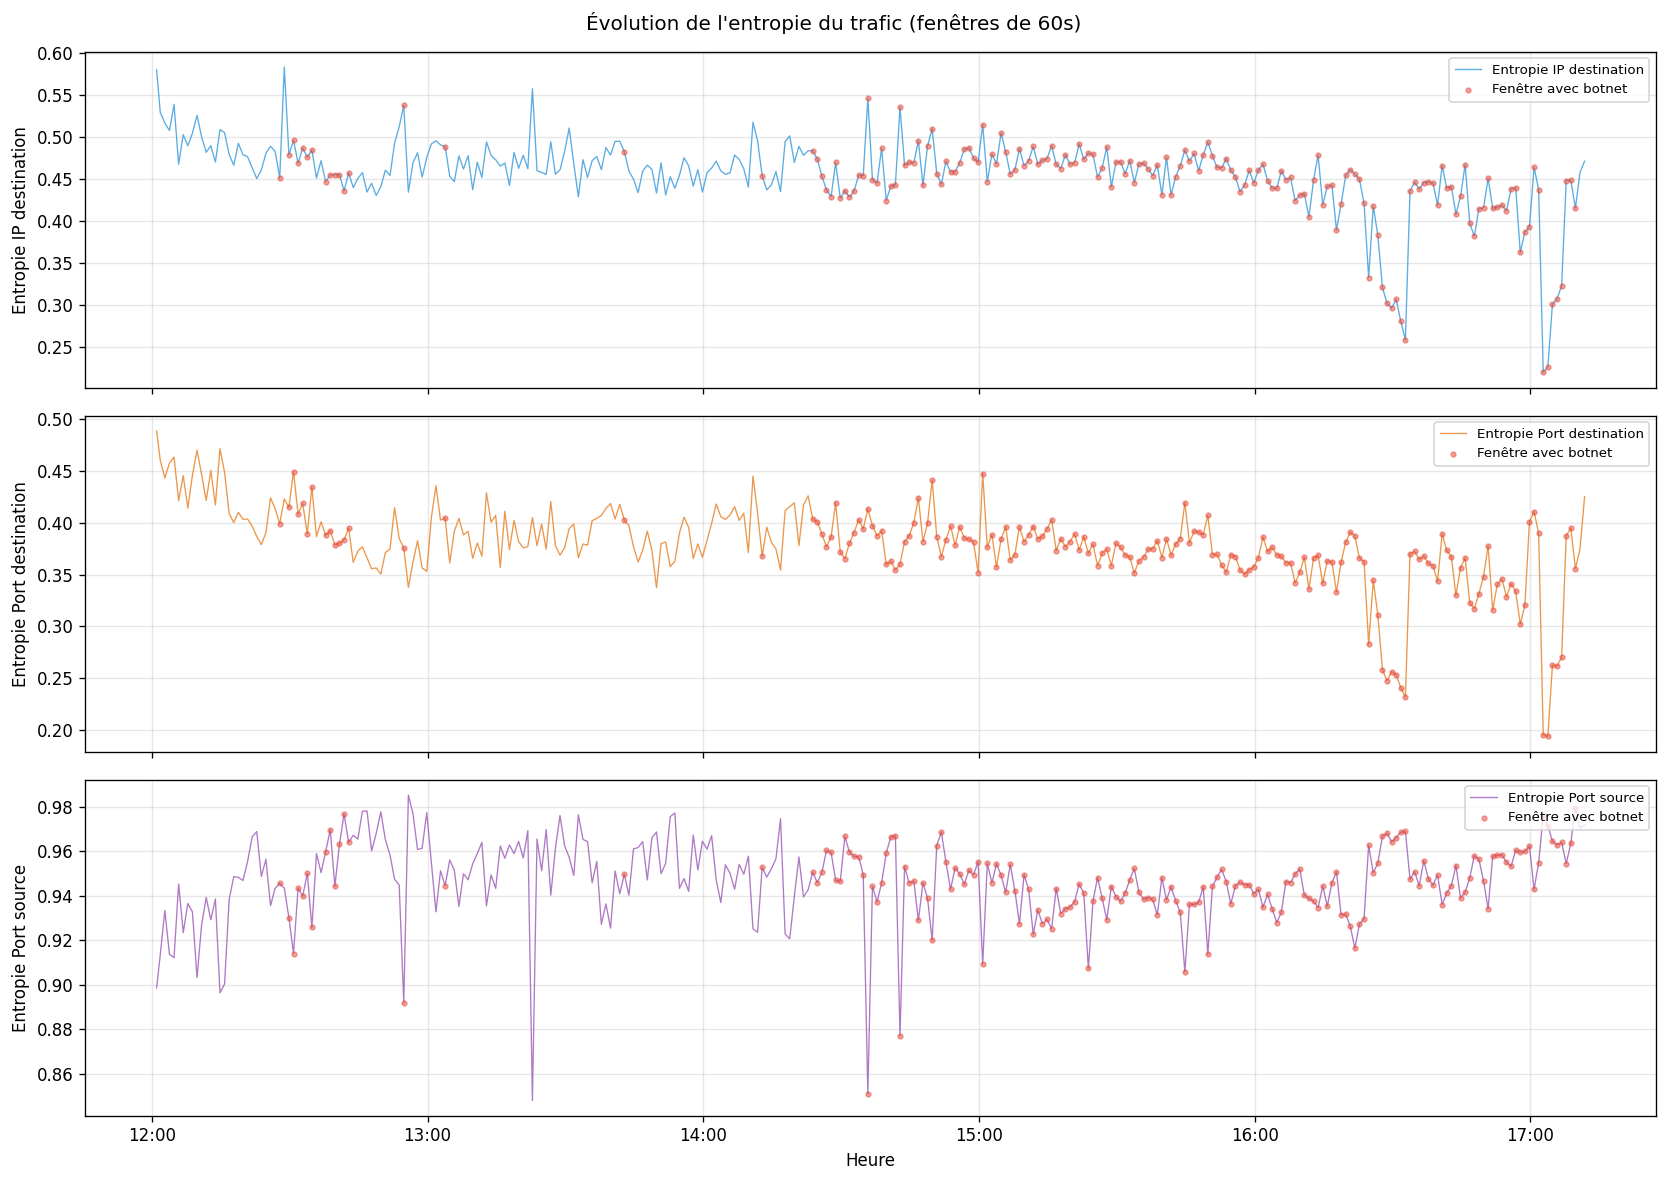

,time,H_dst_ip,H_dst_port,H_src_port,dominant_label,has_botnet,n_flows
0,2011-08-17 12:01:01.780520,0.580175,0.488627,0.898570,Background,False,7231
1,2011-08-17 12:01:49.441506,0.529622,0.460532,0.913384,Background,False,6893
2,2011-08-17 12:02:49.441240,0.516881,0.443311,0.933359,Background,False,5790
3,2011-08-17 12:03:49.449604,0.507996,0.457681,0.913606,Background,False,5721
4,2011-08-17 12:04:49.467017,0.539002,0.463515,0.912136,Background,False,6029


In [99]:
df_entropy_preview = compute_entropy_preview(
    df,
    window_seconds=CONFIG['k_minor'] * 60,
    save_dir=str(RESULTS_DIR),
)
show_saved_figure('entropy_preview.png')
df_entropy_preview.head()

## 2. Chargement des splits locaux

On recharge les mêmes splits temporels que le pipeline principal pour garder une comparaison propre.

In [100]:
df_train, df_val, df_test = load_splits(CONFIG)
print_split_overview(df_train, df_val, df_test)

[LOAD] Chargement des splits depuis les fichiers Parquet...

── Aperçu des splits ─────────────────────────────────────────────
  Train | total=1,252,504 | Botnet=41,397 | Normal=18,863 | Background=1,192,244
  Val   | total= 417,502 | Botnet=75,261 | Normal= 5,618 | Background= 336,623
  Test  | total= 417,502 | Botnet=68,329 | Normal= 5,486 | Background= 343,687


## 3. Préparation des features de l'implémentation originale

Cette étape suit la logique du notebook d'origine :
- filtrage TCP
- extraction des flags TCP
- agrégation par IP source
- entropies sur ports, IP destination et flags

In [101]:
train_features = prepare_original_features(df_train, CONFIG, label='TRAIN')
val_features = prepare_original_features(df_val, CONFIG, label='VAL')
test_features = prepare_original_features(df_test, CONFIG, label='TEST')

pd.Series(
    {
        'train_ips': len(train_features),
        'val_ips': len(val_features),
        'test_ips': len(test_features),
    }
)

[TRAIN] Flows TCP conservés : 256,944
[TRAIN] IPs agrégées : 12,392
[VAL] Flows TCP conservés : 93,750
[VAL] IPs agrégées : 4,045
[TEST] Flows TCP conservés : 80,860
[TEST] IPs agrégées : 3,424


train_ips    12392
val_ips       4045
test_ips      3424
dtype: int64

In [102]:
entropy_columns = [
    'SrcIP',
    'SrcPortEntropy',
    'DestPortEntropy',
    'DestIPEntropy',
    'FlagEntropy',
    'AggregatedLabel',
]
train_features[entropy_columns].head(10)

,SrcIP,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy,AggregatedLabel
0,119.252.172.92,3.000000,-0.000000,-0.000000,-0.000000,0
1,90.183.101.168,-0.000000,-0.000000,-0.000000,-0.000000,0
2,217.169.177.82,4.700440,-0.000000,-0.000000,1.386614,0
3,89.185.253.133,-0.000000,-0.000000,-0.000000,-0.000000,0
4,80.246.200.81,-0.000000,-0.000000,-0.000000,-0.000000,0
5,147.32.80.13,8.628358,2.151238,2.826463,0.879222,0
6,147.32.84.118,12.166531,1.497615,9.247782,2.808026,0
7,195.250.146.100,-0.000000,0.811278,0.811278,1.500000,0
8,147.32.84.134,10.918167,0.956789,6.640321,2.420593,0
9,147.32.84.68,7.592527,1.525560,4.983642,2.553393,0


In [103]:
train_features[list(CONFIG['pca_feature_columns'])].describe()

,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy
count,12392.000000,12392.000000,12392.000000,12392.000000
mean,0.935808,0.366889,0.114369,0.309788
std,1.410563,0.687748,0.683974,0.542278
min,-0.000000,-0.000000,-0.000000,-0.000000
25%,-0.000000,-0.000000,-0.000000,-0.000000
50%,-0.000000,-0.000000,-0.000000,-0.000000
75%,1.584963,0.918296,0.000000,0.811278
max,14.512018,9.172428,9.915879,3.162257


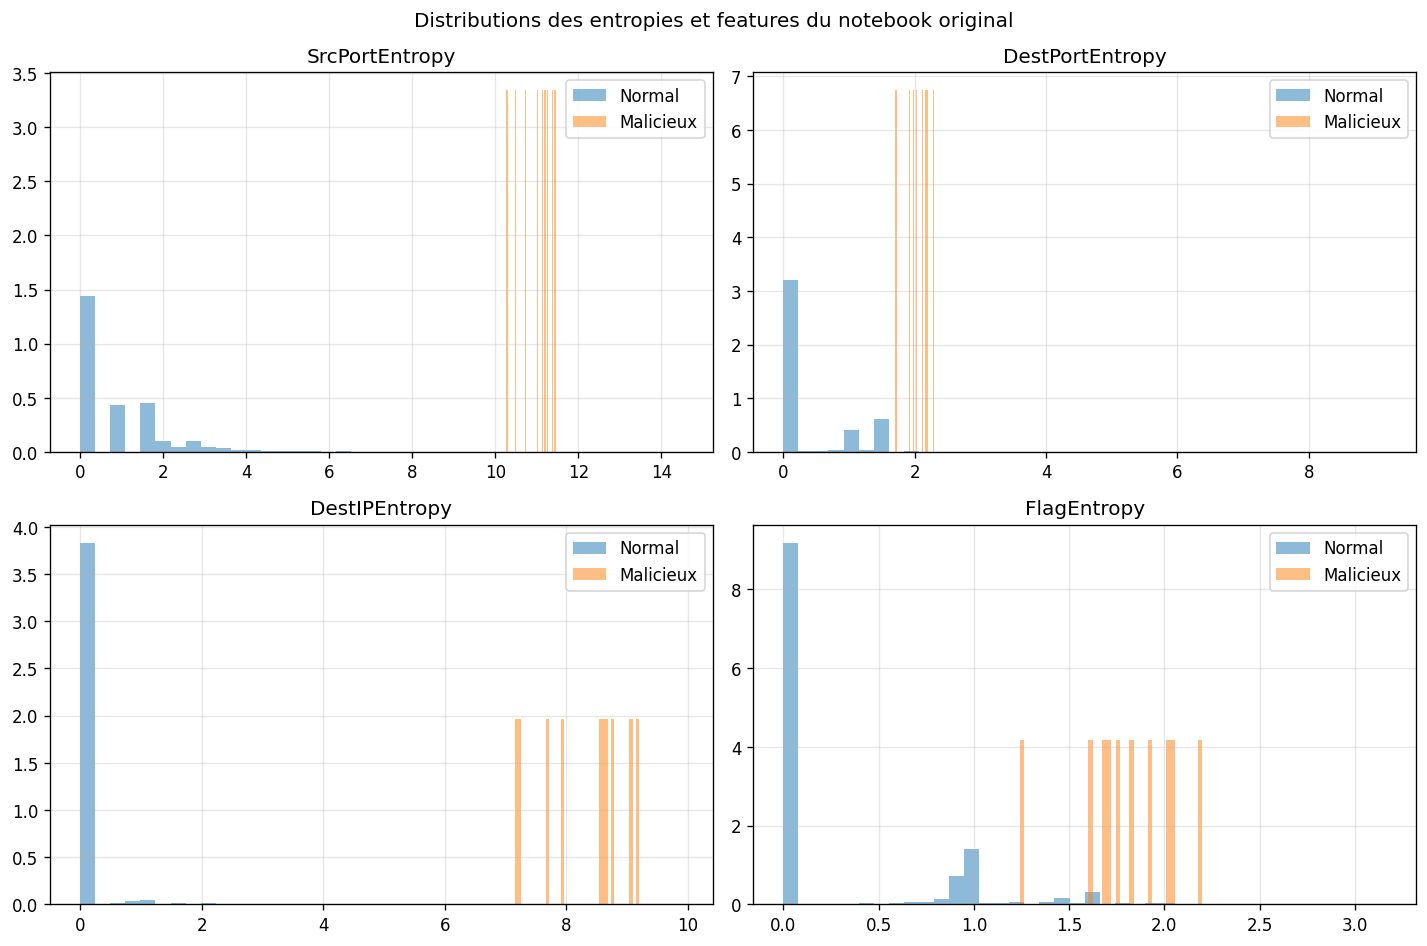

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for ax, feature_name in zip(axes, CONFIG['pca_feature_columns']):
    subsets = {
        'Normal': train_features[train_features['AggregatedLabel'] == 0][feature_name],
        'Malicieux': train_features[train_features['AggregatedLabel'] == 1][feature_name],
    }
    for label, subset in subsets.items():
        if len(subset) == 0:
            continue
        ax.hist(subset, bins=40, alpha=0.5, density=True, label=label)
    ax.set_title(feature_name)
    ax.legend()

plt.suptitle('Distributions des entropies et features du notebook original')
plt.tight_layout()
plt.show()

## 4. PCA sur les features du notebook original

In [105]:
_, pca_model, significant_components, eigenvalues_sig, train_scaled, scaler = perform_pca(
    train_features,
    CONFIG['pca_feature_columns'],
    eigen_threshold=CONFIG['eigen_threshold'],
)

pd.Series(
    {
        'n_components_total': len(pca_model.explained_variance_),
        'n_components_significatives': significant_components.shape[0],
        'variance_expliquee_totale_pct': float(pca_model.explained_variance_ratio_.sum() * 100),
    }
)

n_components_total                 4.0
n_components_significatives        4.0
variance_expliquee_totale_pct    100.0
dtype: float64

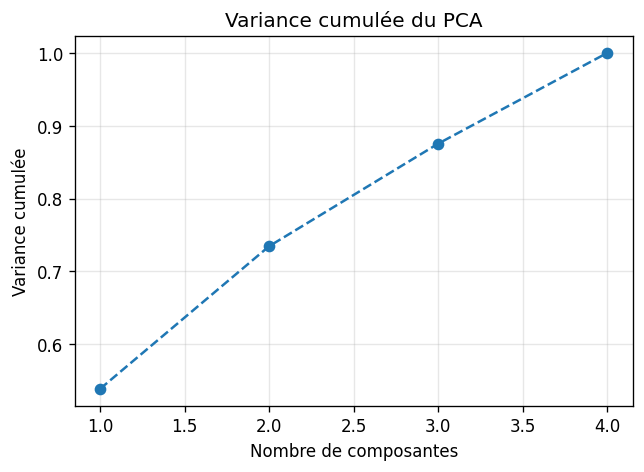

In [106]:
cumulative_variance = pca_model.explained_variance_ratio_.cumsum()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance cumulée')
plt.title('Variance cumulée du PCA')
plt.grid(True)
plt.show()

In [107]:
train_major, train_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    train_scaled,
    significant_components,
    eigenvalues_sig,
)

pd.DataFrame(
    {
        'anomaly_score_major': train_major,
        'anomaly_score_minor': train_minor,
    }
).describe()

,anomaly_score_major,anomaly_score_minor
count,12392.000000,12392.000000
mean,3.514317,2.005810
std,15.712419,6.465587
min,0.130710,0.000005
25%,0.382615,0.135748
50%,0.493005,0.138362
75%,2.939485,1.754155
max,563.714982,258.615006


## 5. Calibration des seuils sur validation

In [108]:
val_matrix = val_features[list(CONFIG['pca_feature_columns'])].values
val_scaled = scaler.transform(val_matrix)
val_major, val_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    val_scaled,
    significant_components,
    eigenvalues_sig,
)
y_val = val_features['AggregatedLabel'].to_numpy(dtype=int)

best_thresholds, results_df = calibrate_thresholds(
    val_major,
    val_minor,
    y_val,
    grid_points=CONFIG['threshold_grid_points'],
)

plot_threshold_heatmap(results_df, CONFIG['results_dir'])
pd.Series(best_thresholds)

[INFO] Figure sauvegardée : results_original/threshold_heatmap.png


threshold_major     121.108714
threshold_minor      44.356867
TP                   10.000000
TN                 4027.000000
FP                    8.000000
FN                    0.000000
FPR                   0.001983
Recall                1.000000
Precision             0.555556
Accuracy              0.998022
F1                    0.714286
N_eval             4045.000000
N_botnet             10.000000
N_normal           4035.000000
dtype: float64

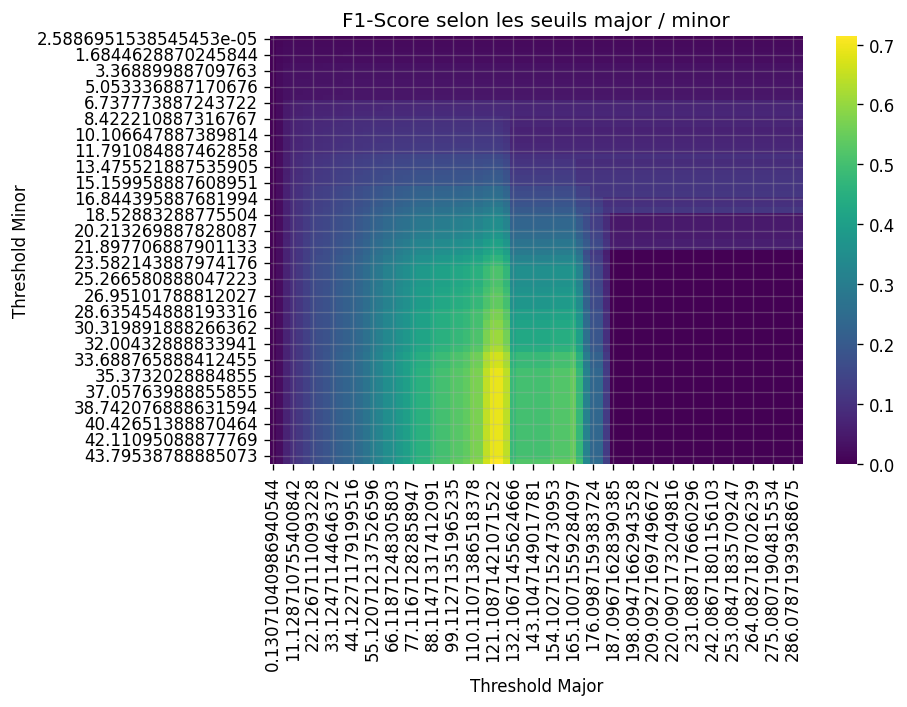

In [109]:
show_saved_figure('threshold_heatmap.png')

## 6. Prédiction sur le test set et évaluation

In [110]:
test_matrix = test_features[list(CONFIG['pca_feature_columns'])].values
test_scaled = scaler.transform(test_matrix)
test_major, test_minor = calculate_anomaly_scores(
    CONFIG['k_minor'],
    test_scaled,
    significant_components,
    eigenvalues_sig,
)
y_test = test_features['AggregatedLabel'].to_numpy(dtype=int)
y_pred = predict_anomalies(
    test_major,
    test_minor,
    best_thresholds['threshold_major'],
    best_thresholds['threshold_minor'],
)

metrics = compute_binary_metrics(y_test, y_pred)
plot_confusion(metrics, CONFIG['results_dir'])
pd.Series(metrics)

[INFO] Figure sauvegardée : results_original/confusion_matrix.png


TP              8.000000
TN           3404.000000
FP             10.000000
FN              2.000000
FPR             0.002929
Recall          0.800000
Precision       0.444444
Accuracy        0.996495
F1              0.571429
N_eval       3424.000000
N_botnet       10.000000
N_normal     3414.000000
dtype: float64

In [111]:
test_results = test_features.copy()
test_results['anomaly_score_major'] = test_major
test_results['anomaly_score_minor'] = test_minor
test_results['Prediction'] = y_pred

report = classification_report(
    y_test,
    y_pred,
    target_names=['Normal', 'Malicieux'],
    zero_division=0,
)
print(report)
test_results.head()

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      3414
   Malicieux       0.44      0.80      0.57        10

    accuracy                           1.00      3424
   macro avg       0.72      0.90      0.78      3424
weighted avg       1.00      1.00      1.00      3424



,SrcIP,TotalFlows,SynFreq,AckFreq,FinFreq,RstFreq,PshFreq,UrgFreq,SrcPortEntropy,DestPortEntropy,DestIPEntropy,FlagEntropy,AggregatedLabel,anomaly_score_major,anomaly_score_minor,Prediction
0,147.32.84.191,2055,0.999027,0.226764,0.162530,0.082725,0.197567,0.0,10.791417,1.436875,8.957865,1.204588,1,173.285912,17.035064,1
1,147.32.84.59,14709,0.991570,0.991774,0.939629,0.249235,0.884085,0.0,13.517992,1.432967,7.346844,2.231667,0,130.964156,3.389246,1
2,147.32.84.134,797,0.996236,1.000000,0.941029,0.365119,0.795483,0.0,9.620870,1.014820,6.295868,2.391377,0,78.272125,20.356200,0
3,147.32.84.192,2562,0.999610,0.391101,0.129196,0.283372,0.165886,0.0,10.955637,1.808887,7.813614,1.674107,1,121.954946,9.465452,1
4,147.32.84.193,2116,0.999527,0.241966,0.173440,0.092628,0.209830,0.0,10.761430,1.552292,8.870845,1.289185,1,166.422348,16.781301,1


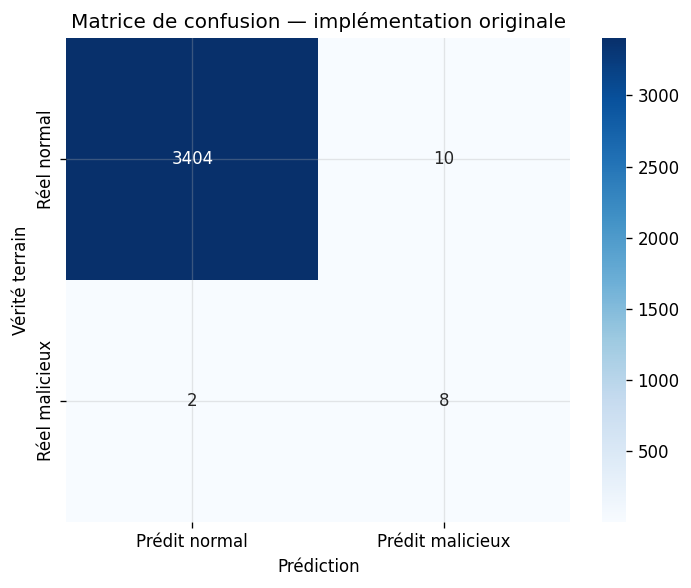

In [112]:
show_saved_figure('confusion_matrix.png')

In [113]:
save_outputs(
    CONFIG,
    train_features=train_features,
    val_features=val_features,
    test_results=test_results,
    metrics=metrics,
    best_thresholds=best_thresholds,
    report=report,
)

pd.Series(
    {
        'results_dir': CONFIG['results_dir'],
        'metrics_path': str(Path(CONFIG['results_dir']) / 'metrics.json'),
        'predictions_path': str(Path(CONFIG['results_dir']) / 'predictions.csv'),
    }
)

results_dir                        results_original/
metrics_path           results_original/metrics.json
predictions_path    results_original/predictions.csv
dtype: str

## 7. Récapitulatif final de tous les scores

Cette dernière cellule rassemble tous les scores de l'implémentation originale,
ainsi que les seuils utilisés.

In [114]:
original_recap = pd.Series(
    {
        'ThresholdMajor': best_thresholds['threshold_major'],
        'ThresholdMinor': best_thresholds['threshold_minor'],
        'TP': metrics['TP'],
        'TN': metrics['TN'],
        'FP': metrics['FP'],
        'FN': metrics['FN'],
        'Precision': metrics['Precision'],
        'Recall': metrics['Recall'],
        'F1': metrics['F1'],
        'FPR': metrics['FPR'],
        'Accuracy': metrics['Accuracy'],
        'N_eval': metrics['N_eval'],
        'N_botnet': metrics['N_botnet'],
        'N_normal': metrics['N_normal'],
    },
    name='original_implementation',
)

display(original_recap.to_frame())

,original_implementation
ThresholdMajor,121.108714
ThresholdMinor,44.356867
TP,8.000000
TN,3404.000000
FP,10.000000
FN,2.000000
Precision,0.444444
Recall,0.800000
F1,0.571429
FPR,0.002929
